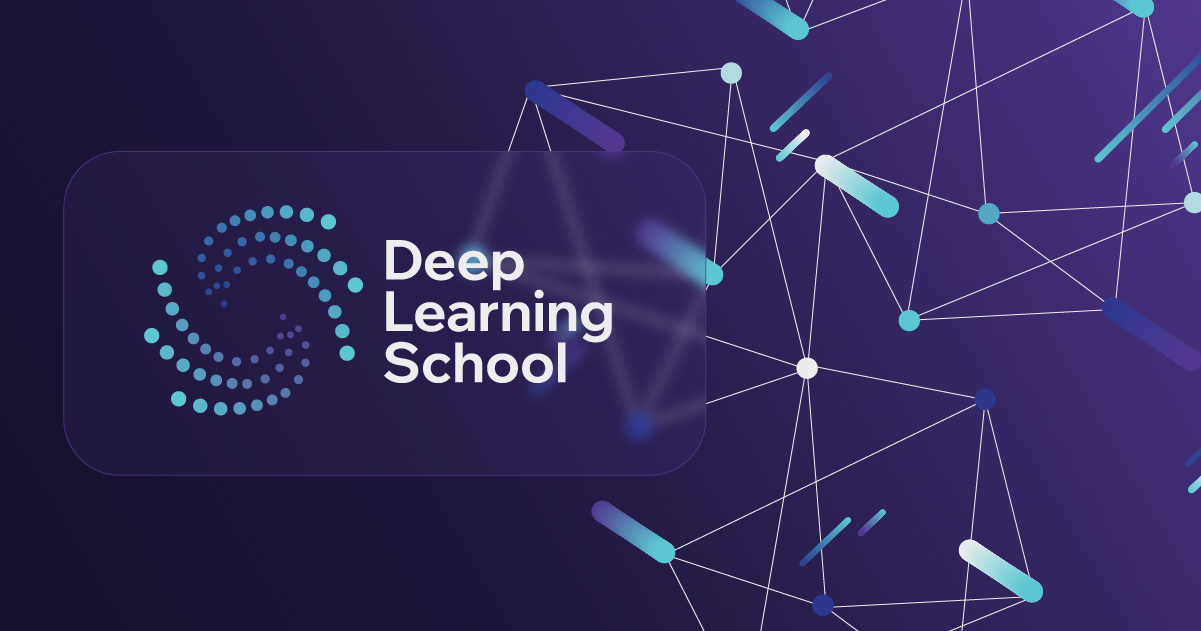

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Решение конкурса на kaggle</b></h1>

https://www.kaggle.com/competitions/advanced-dls-spring-2021/overview

# Первая часть. Исследование

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## Загрузка данных

In [2]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 92.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 68.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 32.3MB/s]


In [39]:
data = pd.read_csv('./train.csv')
train_data = data.copy()

> Выведем 10 случайных строк датасета

In [40]:
train_data.sample(n=10)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1820,1,80.15,80.15,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,No,Credit card (automatic),1
3046,1,45.30,45.3,Male,0,No,No,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,1
3314,26,95.00,2497.2,Female,1,No,No,Yes,Yes,Fiber optic,Yes,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,1
3390,6,20.15,130.5,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),0
2400,57,19.60,1170.55,Male,0,No,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,0
530,22,20.45,471.55,Male,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),0
2482,18,80.65,1451.9,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,1
4115,36,95.00,3440.25,Male,0,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),0
4835,10,45.80,436.2,Male,0,No,No,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),0
2247,50,114.35,5791.1,Male,0,No,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),0


> Выведем общее количество Nan и процентное соотношение Nan для каждого признака

In [41]:
print("Общая информация о пропусках:")
print(train_data.isna().sum())

print("\nПроцент пропусков в каждом столбце:")
print((train_data.isna().sum() / len(train_data) * 100).round(2))

Общая информация о пропусках:
ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
Churn                       0
dtype: int64

Процент пропусков в каждом столбце:
ClientPeriod                0.0
MonthlySpending             0.0
TotalSpent                  0.0
Sex                         0.0
IsSeniorCitizen             0.0
HasPartner                  0.0
HasChild                    0.0
HasPhoneService             0.0
HasMultiplePhoneNumbers     0.0
HasInternetService          0.0


> Обработка пропусков в датасете не требуется.

In [ ]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [43]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

> Заметим, что один из признаков, определенный как числовой (`TotalSpent`) имеет тип object. Преобразуем его в тип float. Значения ' ' заменим на 0.

In [44]:
train_data['TotalSpent'] = pd.to_numeric(train_data['TotalSpent'], errors='coerce')
train_data['TotalSpent'] = train_data['TotalSpent'].fillna(0)

## Анализ данных

1) Для численных призанков построим гистограмму (*plt.hist(...)*). Для категориальных посчитаем количество каждого значения для каждого признака.

2) Проанализируем распределение целевой переменной на сбалансированность классов.

> Распределение числовых признаков

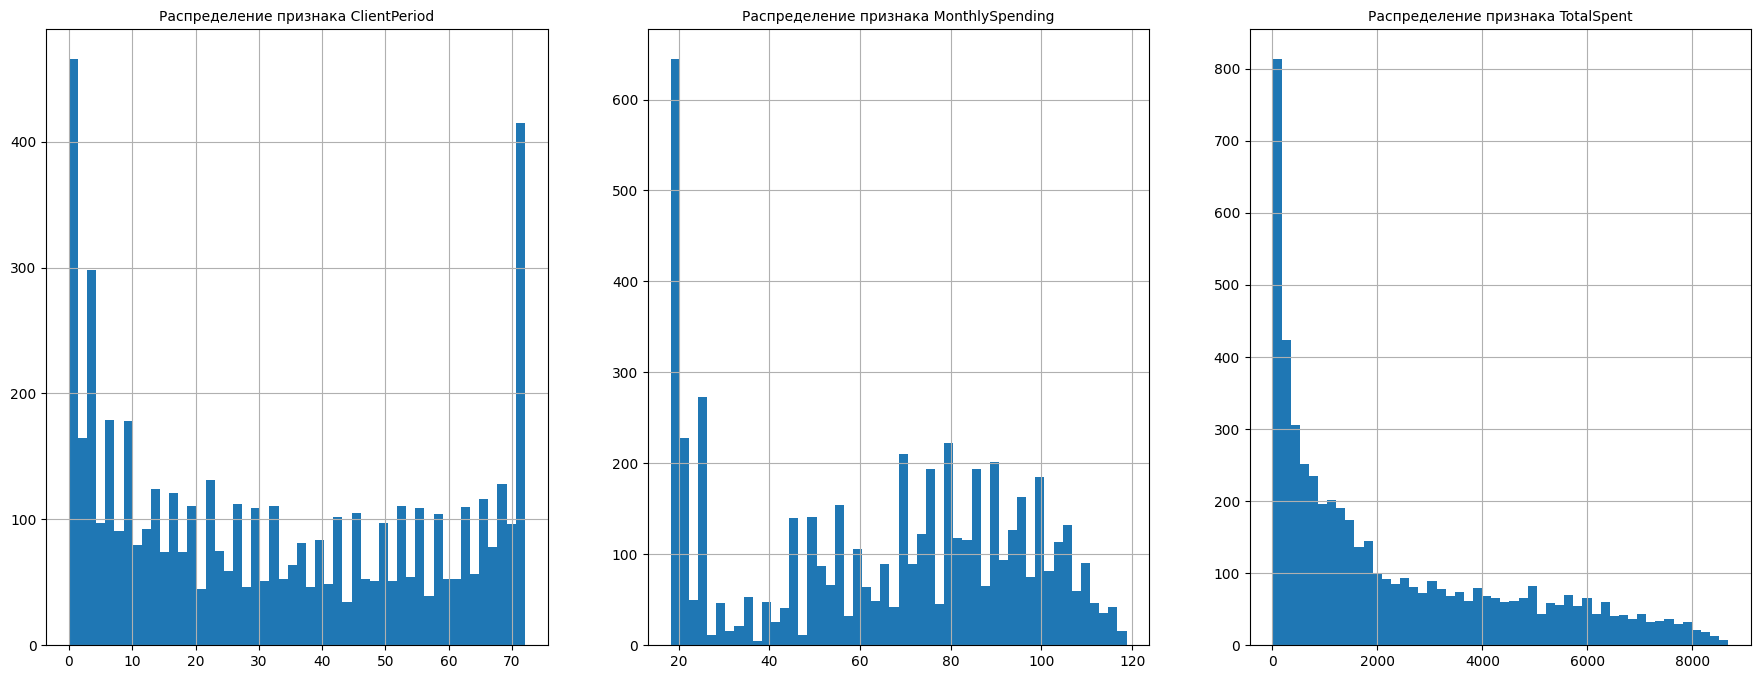

In [45]:
fig, ax = plt.subplots(1, 3, figsize=(22, 8))

ax = ax.ravel()

for i in range(len(num_cols)):

    ax[i].hist(train_data[num_cols[i]], bins=50)

    ax[i].set_title(f'Распределение признака {num_cols[i]}', fontsize=10)

    ax[i].grid()

fig.show()

> Распределение категориальных признаков

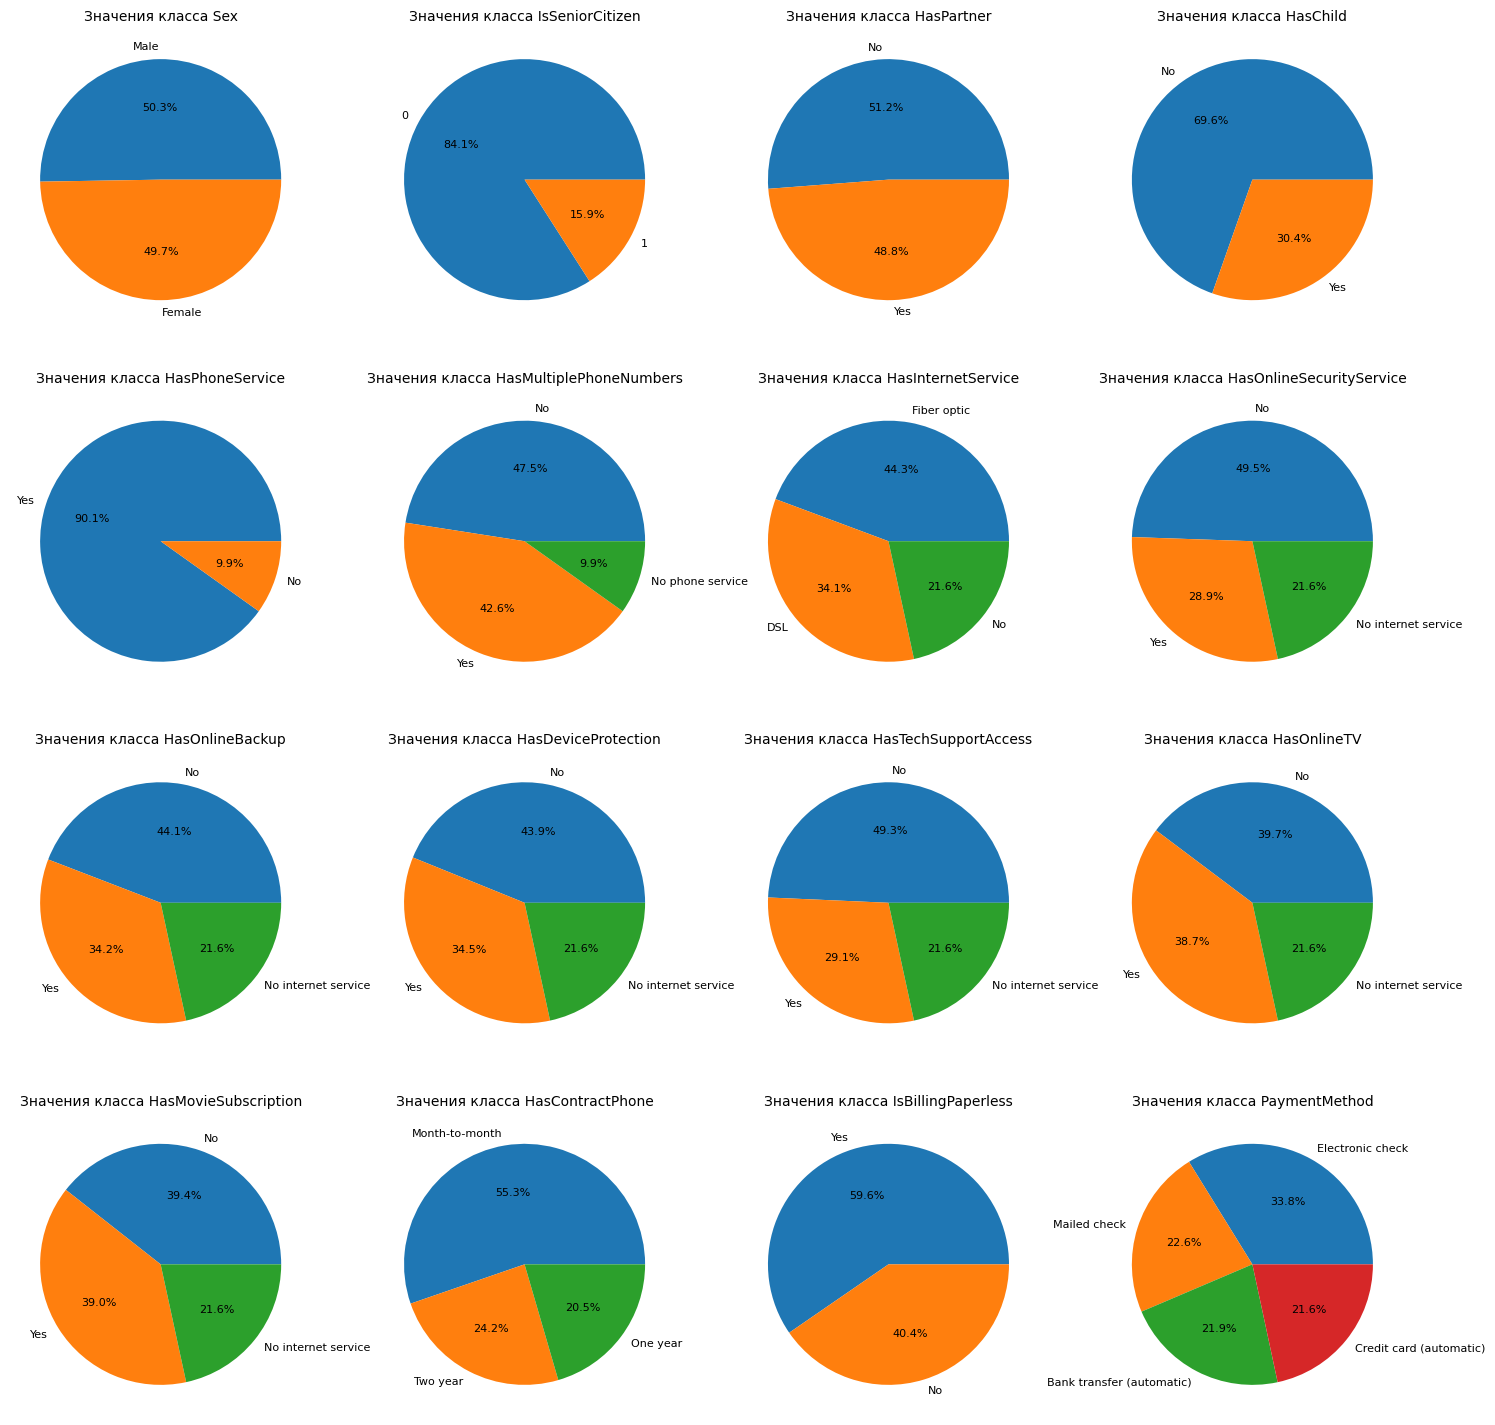

In [46]:
fig, ax = plt.subplots(4, 4, figsize=(18, 18))

ax = ax.ravel()

for i in range(len(cat_cols)):

    plot_data = train_data[cat_cols[i]].value_counts()

    ax[i].pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%', textprops={'fontsize': 8})

    ax[i].set_title(f'Значения класса {cat_cols[i]}', fontsize=10)

fig.show()

> Посмотрим на распределение классов целевой переменной

In [47]:
train_data['Churn'].value_counts()

,count
Churn,
0,3898
1,1384


> Представителей класса 0 больше в 2,8 раза, чем представителей класса 1, что говорит о несбалансированности классов.

> Посмотрим на количество уникальных значений категориальных признаков

In [48]:
for feature in cat_cols:
  print(f'Количество уникальных значений признака {feature}:')
  print(train_data[feature].value_counts(), '\n')

Количество уникальных значений признака Sex:
Sex
Male      2655
Female    2627
Name: count, dtype: int64 

Количество уникальных значений признака IsSeniorCitizen:
IsSeniorCitizen
0    4440
1     842
Name: count, dtype: int64 

Количество уникальных значений признака HasPartner:
HasPartner
No     2705
Yes    2577
Name: count, dtype: int64 

Количество уникальных значений признака HasChild:
HasChild
No     3676
Yes    1606
Name: count, dtype: int64 

Количество уникальных значений признака HasPhoneService:
HasPhoneService
Yes    4761
No      521
Name: count, dtype: int64 

Количество уникальных значений признака HasMultiplePhoneNumbers:
HasMultiplePhoneNumbers
No                  2511
Yes                 2250
No phone service     521
Name: count, dtype: int64 

Количество уникальных значений признака HasInternetService:
HasInternetService
Fiber optic    2341
DSL            1800
No             1141
Name: count, dtype: int64 

Количество уникальных значений признака HasOnlineSecurityServi

> Можно выделить признаки, которые коррелируют между собой. Например, такими признаками являются `HasPhoneService` и `HasMultiplePhoneNumbers`. Для клиентов, о которых известно, имеют они несколько номеров или нет, признак `HasPhoneService` принимает значение 1. Для клиентов с значением признака `HasPhoneService` = 0 соответсвуют записи `HasMultiplePhoneNumbers` = "No phone service". Убедимся в этом, найдя уникальные пары значений этих признаков.

In [49]:
train_data.groupby(["HasPhoneService", "HasMultiplePhoneNumbers"]).size()

HasPhoneService  HasMultiplePhoneNumbers
No               No phone service            521
Yes              No                         2511
                 Yes                        2250
dtype: int64

> Таким образом, из датасета можно убрать признак `HasPhoneService`, т.к. он содержится "внутри" признака `HasMultiplePhoneNumbers`.

In [50]:
train_data = train_data.drop(columns=["HasPhoneService"])

cat_cols.remove("HasPhoneService")

Преобразуем категориальные признаки следующим образом: признаки, принимающие только 2 значения (значение "No service..." приравниваем к "No"), приведем к значениям 0 и 1. Остальные признаки (`HasInternetService`, `HasContractPhone`, `PaymentMethod`) преобразуем с помощью One Hot Encoding.

In [51]:
feature_dict = {'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0, 'Male': 1, 'Female': 0}

for feature in cat_cols:
  if feature not in ['IsSeniorCitizen', 'HasInternetService', 'HasContractPhone', 'PaymentMethod']:
    train_data[feature] = train_data[feature].map(feature_dict)

In [52]:
train_data.loc[train_data['HasInternetService'] == "Fiber optic", 'Internet_FiberOptic'] = 1
train_data.loc[train_data['HasInternetService'] == "DSL", 'Internet_DSL'] = 1

train_data.loc[train_data['HasContractPhone'] == "Month-to-month", 'Contract_Month'] = 1
train_data.loc[train_data['HasContractPhone'] == "Two year", 'Contract_TwoYear'] = 1
train_data.loc[train_data['HasContractPhone'] == "One year", 'Contract_OneYear'] = 1

train_data.loc[train_data['PaymentMethod'] == "Electronic check", 'Payment_Electronic'] = 1
train_data.loc[train_data['PaymentMethod'] == "Mailed check", 'Payment_Mailed'] = 1
train_data.loc[train_data['PaymentMethod'] == "Bank transfer (automatic)", 'Payment_Bank'] = 1
train_data.loc[train_data['PaymentMethod'] == "Credit card (automatic)", 'Payment_Credit'] = 1

train_data = train_data.drop(columns=["HasInternetService", "HasContractPhone", "PaymentMethod"])

train_data = train_data.fillna(0)

In [53]:
from google.colab.data_table import DataTable

DataTable.max_columns = 25
train_data.corr()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasMultiplePhoneNumbers,HasOnlineSecurityService,HasOnlineBackup,...,Churn,Internet_FiberOptic,Internet_DSL,Contract_Month,Contract_TwoYear,Contract_OneYear,Payment_Electronic,Payment_Mailed,Payment_Bank,Payment_Credit
ClientPeriod,1.000000,0.249414,0.826658,0.006370,0.011561,0.370314,0.146120,0.334744,0.334992,0.362714,...,-0.350640,0.017599,0.015139,-0.645405,0.563247,0.197102,-0.206099,-0.221152,0.228857,0.231400
MonthlySpending,0.249414,1.000000,0.652014,-0.011778,0.215456,0.087652,-0.125682,0.485280,0.295535,0.443517,...,0.184769,0.788712,-0.165229,0.058894,-0.070144,0.001918,0.259584,-0.371591,0.040145,0.038878
TotalSpent,0.826658,0.652014,1.000000,0.006341,0.094640,0.308733,0.047241,0.467258,0.418245,0.511000,...,-0.200033,0.360583,-0.052185,-0.444720,0.361197,0.164386,-0.061819,-0.290270,0.177835,0.187132
Sex,0.006370,-0.011778,0.006341,1.000000,0.013207,0.002780,0.014605,-0.003035,-0.012985,-0.007417,...,-0.008325,-0.002824,-0.002214,0.000198,-0.011835,0.012321,0.003415,0.012525,-0.009673,-0.006924
IsSeniorCitizen,0.011561,0.215456,0.094640,0.013207,1.000000,0.016764,-0.217007,0.135267,-0.035052,0.068258,...,0.156872,0.247603,-0.102503,0.143054,-0.117132,-0.051876,0.169778,-0.153740,-0.010942,-0.027889
HasPartner,0.370314,0.087652,0.308733,0.002780,0.016764,1.000000,0.442530,0.134243,0.143668,0.134424,...,-0.148347,-0.006202,0.003045,-0.276996,0.249716,0.076119,-0.085955,-0.091035,0.113065,0.077583
HasChild,0.146120,-0.125682,0.047241,0.014605,-0.217007,0.442530,1.000000,-0.030892,0.080863,0.016453,...,-0.163609,-0.174634,0.050978,-0.228322,0.199604,0.069361,-0.146189,0.062937,0.043363,0.060437
HasMultiplePhoneNumbers,0.334744,0.485280,0.467258,-0.003035,0.135267,0.134243,-0.030892,1.000000,0.106104,0.203648,...,0.039572,0.360535,-0.201747,-0.093057,0.111467,-0.003704,0.078672,-0.227568,0.077057,0.063327
HasOnlineSecurityService,0.334992,0.295535,0.418245,-0.012985,-0.035052,0.143668,0.080863,0.106104,1.000000,0.287962,...,-0.182871,-0.032486,0.324952,-0.250423,0.199205,0.097011,-0.108539,-0.081472,0.080191,0.126853
HasOnlineBackup,0.362714,0.443517,0.511000,-0.007417,0.068258,0.134424,0.016453,0.203648,0.287962,1.000000,...,-0.088003,0.167245,0.153641,-0.171758,0.116962,0.087418,-0.006474,-0.175433,0.089711,0.095471




> Для признака `TotalSpent` наблюдается корреляция между признаками `ClientPeriod` (0.83) и `MonthlySpending` (0.65). Предположим, что ${TotalSpend} \approx {ClientPeriod} + {MonthlySpending}$:



In [54]:
(train_data['MonthlySpending'] * train_data['ClientPeriod'] - train_data['TotalSpent']).describe()[['mean', 'min', 'max']]

,0
mean,0.623031
min,-373.250000
max,370.850000


> В среднем действительно ${TotalSpend} \approx {ClientPeriod} + {MonthlySpending}$, то есть признаки взаимозаменямы. Также заметим, что из всех трех признаков сильнее всех с целевой переменной коррелирует `ClientPeriod`. Поэтому оставим признаки `ClientPeriod` и `MonthlySpending`, а `TotalSpend` удалим.

In [55]:
train_data = train_data.drop(columns=["TotalSpent"])

## Применение линейных моделей

1) Нормировка числовых признаков и кодирование категориальных с помощью one-hot-encoding'а.

2) Подбор гиперпараметра C по метрике ROC-AUC.

In [56]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import make_pipeline

In [147]:
def preprocessing_data(data: pd.DataFrame):
    # Список категориальных признаков
    cat_cols = [
      'Sex',
      'IsSeniorCitizen',
      'HasPartner',
      'HasChild',
      'HasMultiplePhoneNumbers',
      'HasInternetService',
      'HasOnlineSecurityService',
      'HasOnlineBackup',
      'HasDeviceProtection',
      'HasTechSupportAccess',
      'HasOnlineTV',
      'HasMovieSubscription',
      'HasContractPhone',
      'IsBillingPaperless',
      'PaymentMethod'
    ]

    # Словарь значений категориальных признаков для OHE
    feature_dict = {
        'Yes': 1,
        'No': 0,
        'No phone service': 0,
        'No internet service': 0,
        'Male': 1,
        'Female': 0
    }

    X = data.copy()

    # Преобразуем категориальные признаки в числовые
    for feature in cat_cols:
      if feature not in ['IsSeniorCitizen', 'HasInternetService', 'HasContractPhone', 'PaymentMethod']:
        X[feature] = X[feature].map(feature_dict)

    # OHE преобразование
    X.loc[X['HasInternetService'] == "Fiber optic", 'Internet_FiberOptic'] = 1
    X.loc[X['HasInternetService'] == "DSL", 'Internet_DSL'] = 1

    X.loc[X['HasContractPhone'] == "Month-to-month", 'Contract_Month'] = 1
    X.loc[X['HasContractPhone'] == "Two year", 'Contract_TwoYear'] = 1
    X.loc[X['HasContractPhone'] == "One year", 'Contract_OneYear'] = 1

    X.loc[X['PaymentMethod'] == "Electronic check", 'Payment_Electronic'] = 1
    X.loc[X['PaymentMethod'] == "Mailed check", 'Payment_Mailed'] = 1
    X.loc[X['PaymentMethod'] == "Bank transfer (automatic)", 'Payment_Bank'] = 1
    X.loc[X['PaymentMethod'] == "Credit card (automatic)", 'Payment_Credit'] = 1

    X = X.fillna(0)

    # Удаляем неиспользуемые признаки
    X = X.drop(columns=["HasPhoneService", "HasInternetService", "HasContractPhone", "PaymentMethod", "TotalSpent"])

    # Нормализуем данные
    scaler_period = RobustScaler()
    scaler_period.fit(X)
    X = scaler_period.transform(X)

    return X

In [148]:
preprocessing_data = FunctionTransformer(preprocessing_data)

In [189]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['Churn']), data['Churn'], train_size=0.8, random_state=42)

In [155]:
model = make_pipeline(preprocessing_data, LogisticRegression())

param_grid = {
  'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
  'logisticregression__penalty': ['l1', 'l2'],
  'logisticregression__solver': ['liblinear', 'saga'],
  'logisticregression__max_iter': [100, 250, 500, 1000],
  'logisticregression__class_weight': ['balanced', {0: 0.25, 1: 0.75}, None]
}

CV_model = GridSearchCV(estimator=model,
                        param_grid=param_grid,
                        cv=5,
                        scoring='roc_auc',
                        n_jobs=-1,
                        verbose=10,
                        error_score='raise')

CV_model.fit(X_train, y_train.values)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('functiontransformer',
                                        FunctionTransformer(func=<function preprocessing_data at 0x7eeafc57b7e0>)),
                                       ('logisticregression',
                                        LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.001, 0.01, 0.1, 1, 10,
                                                   100],
                         'logisticregression__class_weight': ['balanced',
                                                              {0: 0.25,
                                                               1: 0.75},
                                                              None],
                         'logisticregression__max_iter': [100, 250, 500, 1000],
                         'logisticregression__penalty': ['l1', 'l2'],
                         'logisticregression__solver': ['liblinear', 'saga']},
             scoring='roc_auc', verbose=10)

In [162]:
print('Best params: ', CV_model.best_params_)
print('Best ROC-AUC: ', CV_model.best_score_)

Best params:  {'logisticregression__C': 10, 'logisticregression__class_weight': None, 'logisticregression__max_iter': 100, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}
Best ROC-AUC:  0.8468811046611139


In [163]:
from sklearn.metrics import roc_auc_score

best_model = CV_model.best_estimator_

y_pred = best_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_test.values, y_pred)
print("ROC_AUC : %.4f" % train_auc)

ROC_AUC : 0.8273


Лучшее качество:

Обучающая выборка:

ROC-AUC:  0.8469

Валидационная выборка:

ROC-AUC : 0.8273

Тестовая выборка:

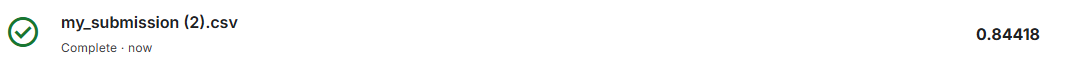

## Применение градиентного бустинга

In [177]:
!pip install catboost -q

In [190]:
import catboost

cat_cols = [
  'Sex',
  'IsSeniorCitizen',
  'HasPartner',
  'HasChild',
  'HasMultiplePhoneNumbers',
  'HasInternetService',
  'HasOnlineSecurityService',
  'HasOnlineBackup',
  'HasDeviceProtection',
  'HasTechSupportAccess',
  'HasOnlineTV',
  'HasMovieSubscription',
  'HasContractPhone',
  'IsBillingPaperless',
  'PaymentMethod'
]

X_train_cat = X_train.copy()
X_train_cat = X_train_cat.drop(columns=["HasPhoneService", "TotalSpent"])

X_test_cat = X_test.copy()
X_test_cat = X_test_cat.drop(columns=["HasPhoneService", "TotalSpent"])

boosting_model = catboost.CatBoostClassifier(n_estimators=200, cat_features=cat_cols)

boosting_model.fit(X_train_cat, y_train.values)

y_train_predicted = boosting_model.predict_proba(X_train_cat)[:, 1]
y_test_predicted = boosting_model.predict_proba(X_test_cat)[:, 1]

Learning rate set to 0.083391
0:	learn: 0.6389649	total: 18ms	remaining: 3.59s
1:	learn: 0.5954179	total: 35.7ms	remaining: 3.54s
2:	learn: 0.5661798	total: 44.2ms	remaining: 2.9s
3:	learn: 0.5371597	total: 57.7ms	remaining: 2.83s
4:	learn: 0.5131236	total: 72.6ms	remaining: 2.83s
5:	learn: 0.4932564	total: 86.5ms	remaining: 2.8s
6:	learn: 0.4803701	total: 96.3ms	remaining: 2.65s
7:	learn: 0.4662358	total: 111ms	remaining: 2.67s
8:	learn: 0.4559692	total: 126ms	remaining: 2.66s
9:	learn: 0.4477837	total: 138ms	remaining: 2.63s
10:	learn: 0.4409832	total: 151ms	remaining: 2.59s
11:	learn: 0.4372078	total: 159ms	remaining: 2.5s
12:	learn: 0.4337044	total: 168ms	remaining: 2.41s
13:	learn: 0.4281904	total: 183ms	remaining: 2.44s
14:	learn: 0.4231578	total: 199ms	remaining: 2.45s
15:	learn: 0.4196198	total: 215ms	remaining: 2.48s
16:	learn: 0.4167160	total: 229ms	remaining: 2.47s
17:	learn: 0.4147757	total: 237ms	remaining: 2.39s
18:	learn: 0.4123224	total: 251ms	remaining: 2.4s
19:	learn:

In [191]:
train_auc = roc_auc_score(y_train.values, y_train_predicted)
test_auc = roc_auc_score(y_test.values, y_test_predicted)

In [193]:
print('Обучающая выборка: ', train_auc)
print('Валидационная выборка: ', test_auc)

Обучающая выборка:  0.8903287440275927
Валидационная выборка:  0.8262945484434019


In [194]:
model_cat_cv = catboost.CatBoostClassifier(n_estimators=200, cat_features=cat_cols, eval_metric='AUC')

grid = {'learning_rate': [0.03, 0.1, 0.3],
        'depth': [4, 6, 10],
        'l2_leaf_reg': np.linspace(0, 1, 20)}

model_cat_cv.grid_search(grid, X=X_train_cat, y= y_train.values)

y_train_pred_grid = model_cat_cv.predict_proba(X_train_cat)[:, 1]
y_test_pred_grid = model_cat_cv.predict_proba(X_test_cat)[:, 1]

Выходные данные были обрезаны до нескольких последних строк (5000).
148:	test: 0.7985248	best: 0.8175538 (8)	total: 9.34s	remaining: 3.2s
149:	test: 0.7985105	best: 0.8175538 (8)	total: 9.4s	remaining: 3.13s
150:	test: 0.7985464	best: 0.8175538 (8)	total: 9.45s	remaining: 3.07s
151:	test: 0.7976406	best: 0.8175538 (8)	total: 9.54s	remaining: 3.01s
152:	test: 0.7971230	best: 0.8175538 (8)	total: 9.61s	remaining: 2.95s
153:	test: 0.7974321	best: 0.8175538 (8)	total: 9.66s	remaining: 2.89s
154:	test: 0.7975472	best: 0.8175538 (8)	total: 9.72s	remaining: 2.82s
155:	test: 0.7970655	best: 0.8175538 (8)	total: 9.77s	remaining: 2.76s
156:	test: 0.7970655	best: 0.8175538 (8)	total: 9.84s	remaining: 2.69s
157:	test: 0.7971877	best: 0.8175538 (8)	total: 9.89s	remaining: 2.63s
158:	test: 0.7968858	best: 0.8175538 (8)	total: 9.94s	remaining: 2.56s
159:	test: 0.7968642	best: 0.8175538 (8)	total: 10s	remaining: 2.5s
160:	test: 0.7968211	best: 0.8175538 (8)	total: 10.1s	remaining: 2.44s
161:	test: 0.7

In [196]:
train_auc = roc_auc_score(y_train.values, y_train_pred_grid)
test_auc = roc_auc_score(y_test.values, y_test_pred_grid)

print('Обучающая выборка: ', train_auc)
print('Валидационная выборка: ', test_auc)

Обучающая выборка:  0.8742966604379505
Валидационная выборка:  0.8271972922304006


Параметры, с которыми достигается лучшее качество:

In [202]:
model_cat_cv.get_params()

{'eval_metric': 'AUC',
 'n_estimators': 200,
 'cat_features': ['Sex',
  'IsSeniorCitizen',
  'HasPartner',
  'HasChild',
  'HasMultiplePhoneNumbers',
  'HasInternetService',
  'HasOnlineSecurityService',
  'HasOnlineBackup',
  'HasDeviceProtection',
  'HasTechSupportAccess',
  'HasOnlineTV',
  'HasMovieSubscription',
  'HasContractPhone',
  'IsBillingPaperless',
  'PaymentMethod'],
 'depth': 4,
 'learning_rate': 0.1,
 'l2_leaf_reg': 0.9473684210526316}

Обучающая выборка:

ROC-AUC:  0.8743

Валидационная выборка:

ROC_AUC : 0.8272

Тестовая выборка:

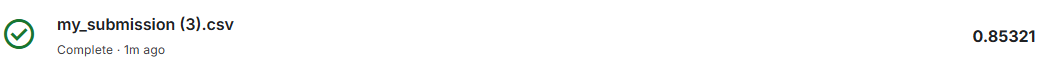

# Предсказания

In [205]:
best_model = model_cat_cv

In [206]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv', index_col='Id')

X_test_cat = X_test.copy()
X_test_cat = X_test_cat.drop(columns=["HasPhoneService", "TotalSpent"])

submission['Churn'] = best_model.predict_proba(X_test_cat)[:, 1]
submission.to_csv('./my_submission.csv')